In [38]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [39]:
class qeState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    dis: float
    result: str

In [40]:
def show_equation(state: qeState):

    equation = f"{state['a']}x^2{state['b']}x{state['c']}"

    return {"equation": equation}

In [41]:
def cal_dis(state: qeState):

    dis = state['b'] ** 2 - 4 * state['a'] * state['c']

    return {"dis": dis}

In [48]:
def real_roots(state: qeState):

    root1 = (-state['b'] + (state['dis'] ** 0.5)) / (2 * state['a'])
    root2 = (-state['b'] - (state['dis'] ** 0.5)) / (2 * state['a'])

    result = f"Root 1: {root1}, Root 2: {root2}"
    return {"result": result}

In [50]:
def repeated_roots(state: qeState):

    root = (-state['b'] / (2 * state['a']))

    result = f"only repeating root is: {root}"
    return {"result": result}

def no_real_roots(state: qeState):

    result = f"No Real Roots"
    return {"result": result}

def check_condition(state: qeState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state['dis'] > 0:
        return "real_roots"
    elif state['dis'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [51]:
graph =  StateGraph(qeState)

graph.add_node('show_equation', show_equation)
graph.add_node('cal_dis', cal_dis)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)
#graph.add_node('show_result', show_result)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'cal_dis')

graph.add_conditional_edges('cal_dis', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

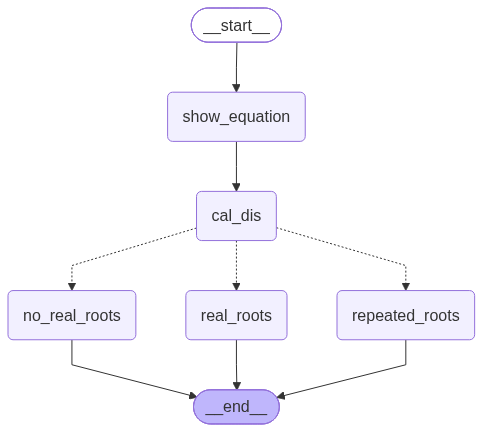

In [52]:
workflow

In [64]:
initial_state = {
    "a": 2,
    "b": 4,
    "c": 2,
}

workflow.invoke(initial_state)


{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^24x2',
 'dis': 0,
 'result': 'only repeating root is: -1.0'}